In [135]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [136]:
import matplotlib
np.__version__, pd.__version__, sns.__version__, matplotlib.__version__

('2.3.2', '2.3.1', '0.13.2', '3.10.5')

In [137]:
df = pd.read_csv('insurance.csv')

In [138]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [139]:
df.shape

(1338, 7)

In [140]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [142]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [143]:
df.rename(columns = {'age':'age', 'sex':'sex', 'bmi':'bmi', 'children':'children', 'smoker':'smoker', 'region':'region', 'charges':'charges', 'region': 'region', 'charges': 'charges'}, inplace = True)

In [144]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

<Axes: xlabel='smoker', ylabel='count'>

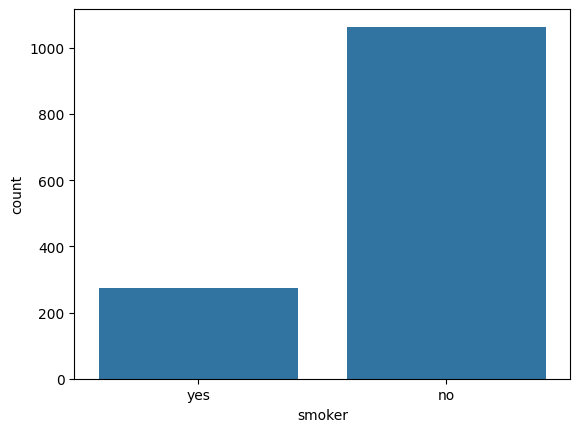

In [145]:
sns.countplot(data = df, x = 'smoker')

<Axes: xlabel='region', ylabel='count'>

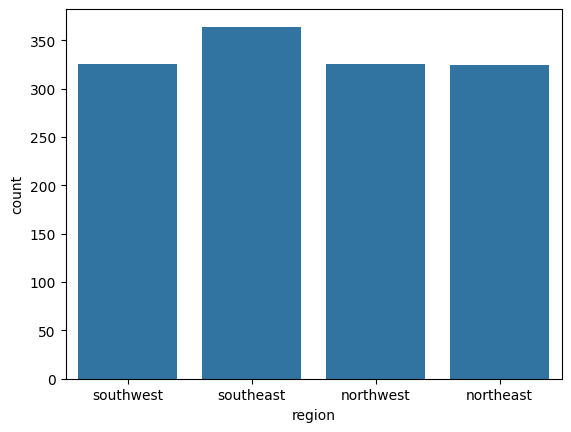

In [146]:
sns.countplot(data= df, x = 'region')

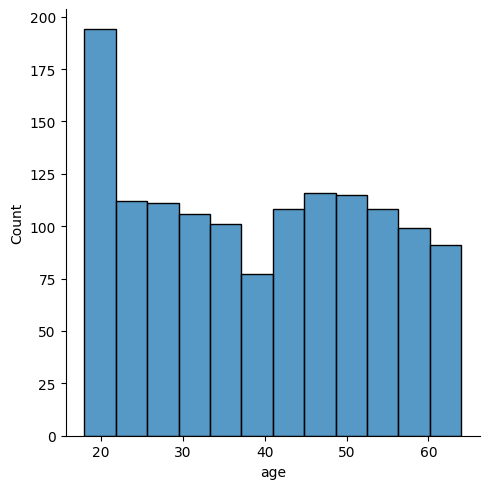

In [147]:
sns.displot(data = df, x = 'age')

Text(0.5, 0, 'age')

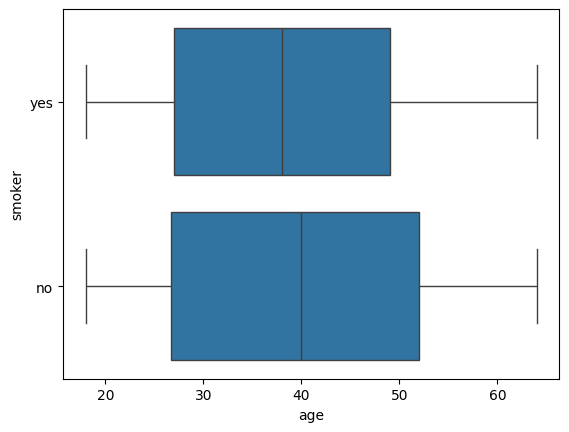

In [148]:
sns.boxplot(x = df["age"], y = df["smoker"]);
plt.ylabel("smoker")
plt.xlabel("age")

<Axes: xlabel='age', ylabel='smoker'>

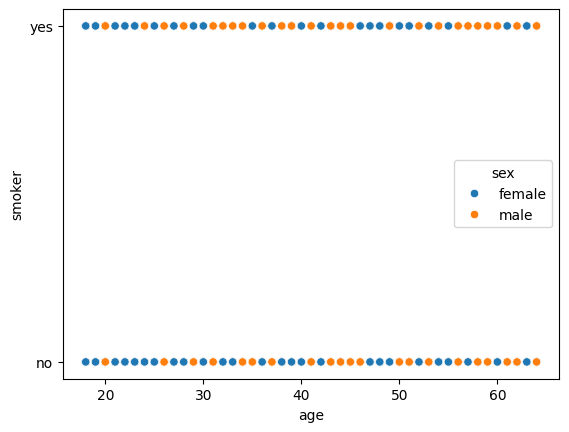

In [149]:
sns.scatterplot(x = df['age'], y = df['smoker'], hue=df['sex'])

In [150]:
df = df.drop(['region'], axis='columns')

In [151]:
df.shape

(1338, 6)

In [152]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker      charges
0      19  female  27.900         0    yes  16884.92400
1      18    male  33.770         1     no   1725.55230
2      28    male  33.000         3     no   4449.46200
3      33    male  22.705         0     no  21984.47061
4      32    male  28.880         0     no   3866.85520
...   ...     ...     ...       ...    ...          ...
1333   50    male  30.970         3     no  10600.54830
1334   18  female  31.920         0     no   2205.98080
1335   18  female  36.850         0     no   1629.83350
1336   21  female  25.800         0     no   2007.94500
1337   61  female  29.070         0    yes  29141.36030

[1338 rows x 6 columns]>

In [153]:
df["smoker"].unique()

array(['yes', 'no'], dtype=object)

In [154]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["smoker"] = le.fit_transform(df["smoker"])

df["smoker"].unique()

array([1, 0])

In [155]:
le.transform(np.array(["no", "yes"]))

array([0, 1])

<Axes: >

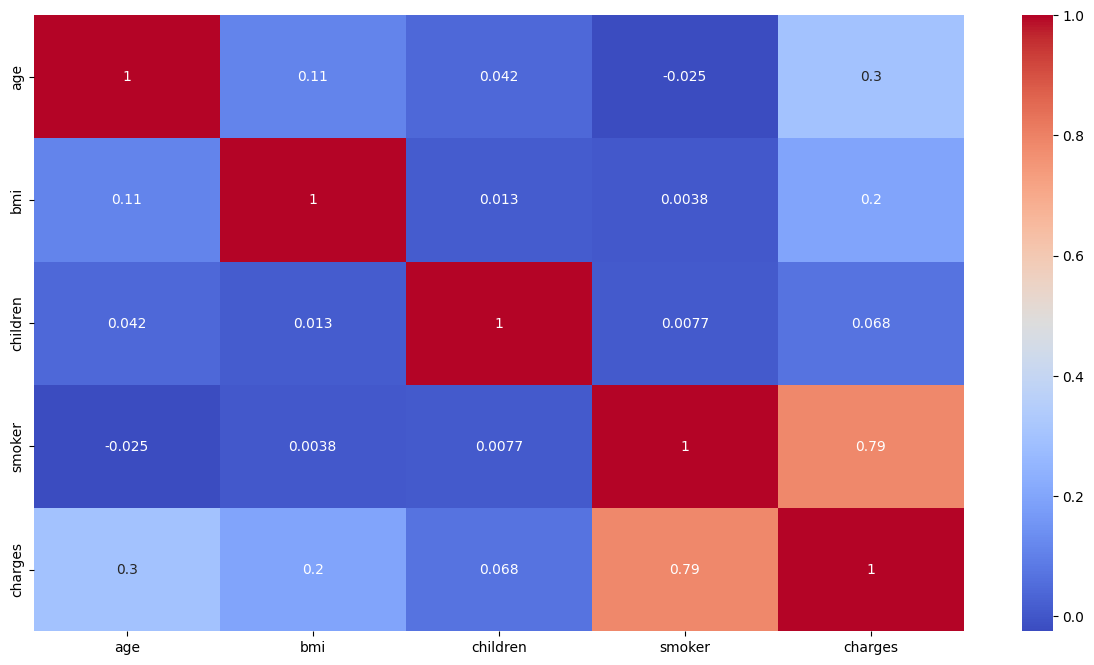

In [156]:
plt.figure(figsize = (15,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [157]:
X = df[ [ 'age', 'smoker','bmi']]

y = df['charges']

In [158]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

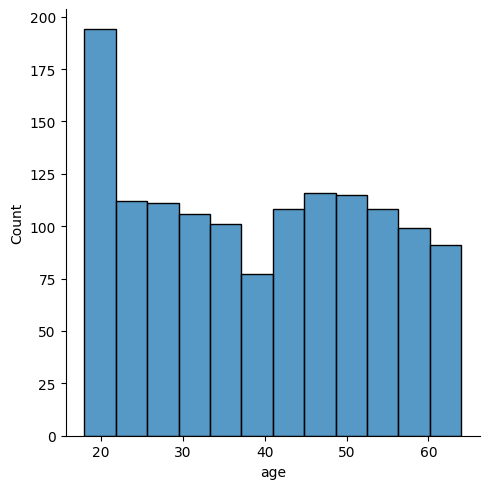

In [159]:
sns.displot(data=df, x='age')

<Axes: xlabel='smoker', ylabel='count'>

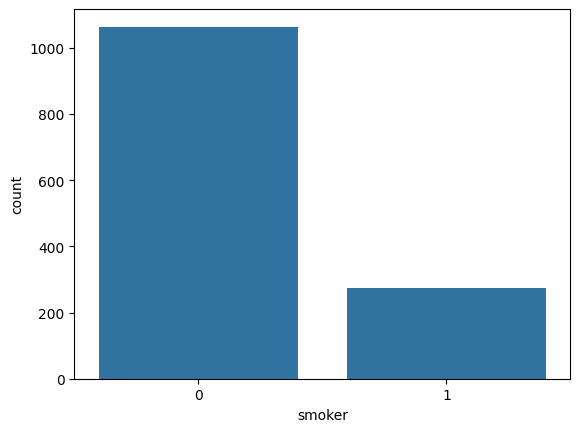

In [160]:
sns.countplot(data=df, x='smoker')

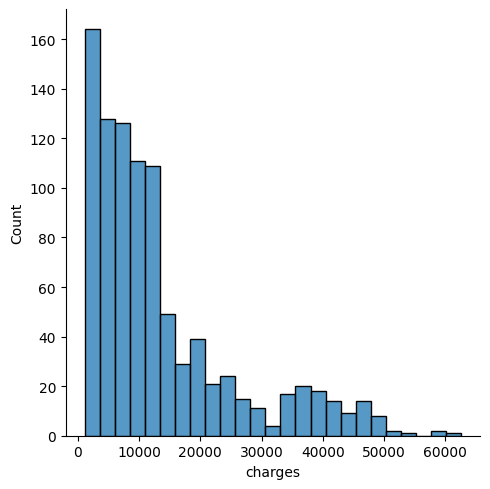

In [161]:
sns.displot(y_train)

In [162]:
X_train[['age', 'smoker']].isna().sum()

age       0
smoker    0
dtype: int64

In [163]:
y_train.isna().sum(), y_test.isna().sum()

(np.int64(0), np.int64(0))

In [164]:
# col_dict = {'age':1,'smoker':2}

# Detect outliers in each variable using box plots.
#plt.figure(figsize=(20,30))

#for variable,i in col_dict.items():
                    # plt.subplot(5,4,i)
                     #plt.boxplot(X_train[variable])
                     #plt.title(variable)

#plt.show()


In [165]:
def outlier_count(col, data = X_train):
    
    q75, q25 = np.percentile(data[col], [75, 25])
    
    # calculate your inter quatile
    iqr = q75 - q25
    
    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    
    # count number of outliers, which are the data that are less than min_val or more than max_val calculated above
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    
    # calculate the percentage of the outliers
    outlier_percent = round(outlier_count/len(data[col])*100, 2)
    
    if(outlier_count > 0):
        print("\n"+15*'-' + col + 15*'-'+"\n")
        print('Number of outliers: {}'.format(outlier_count))
        print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [166]:
for col in X_train.columns:
    outlier_count(col)


---------------smoker---------------

Number of outliers: 195
Percent of data that is outlier: 20.83%

---------------bmi---------------

Number of outliers: 6
Percent of data that is outlier: 0.64%


In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [168]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (936, 3)
Shape of X_test:  (402, 3)
Shape of y_train:  (936,)
Shape of y_test:  (402,)


In [169]:
from sklearn.linear_model import LinearRegression  #we are using regression models
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
yhat = lr.predict(X_test)

print("MSE: ", mean_squared_error(y_test, yhat))
print("r2: ", r2_score(y_test, yhat))

MSE:  34382251.77765592
r2:  0.7655078324224212


In [170]:
from sklearn.linear_model import LinearRegression 
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

algorithms = [LinearRegression(), SVR(), KNeighborsRegressor(), DecisionTreeRegressor(random_state = 0), 
              RandomForestRegressor(n_estimators = 100, random_state = 0)]

algorithm_names = ["Linear Regression", "SVR", "KNeighbors Regressor", "Decision-Tree Regressor", "Random-Forest Regressor"]

In [171]:

y_train.isna().sum()

np.int64(0)

In [172]:
from sklearn.model_selection import KFold, cross_val_score

#lists for keeping mse
train_mse = []
test_mse = []

#defining splits
kfold = KFold(n_splits=5, shuffle=True)

for i, model in enumerate(algorithms):
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
    print(f"{algorithm_names[i]} - Score: {scores}; Mean: {scores.mean()}")

Linear Regression - Score: [-40437904.77192912 -40345710.40730222 -32642466.96673059
 -40427356.1202191  -39271209.21109316]; Mean: -38624929.49545483
SVR - Score: [-1.27422227e+08 -2.00411909e+08 -2.05497877e+08 -1.24543542e+08
 -1.46468614e+08]; Mean: -160868833.95519906
KNeighbors Regressor - Score: [-29980254.52062272 -19343356.61084224 -30149076.08607024
 -27260029.56968282 -30731802.23138414]; Mean: -27492903.803720433
Decision-Tree Regressor - Score: [-53114404.63616707 -31051597.60979751 -47212033.05743091
 -51881586.87767469 -54517154.99738671]; Mean: -47555355.43569138
Random-Forest Regressor - Score: [-24433831.4972976  -19698383.55667618 -33163418.47636672
 -39207163.37587129 -28568640.3093604 ]; Mean: -29014287.44311444


In [179]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for KNeighborsRegressor
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

knn = KNeighborsRegressor()

grid = GridSearchCV(estimator = knn, 
                    param_grid = param_grid, 
                    cv = kfold, 
                    n_jobs = -1, 
                    return_train_score=True, 
                    refit=True,
                    scoring='neg_mean_squared_error')

# Fit your grid_search
grid.fit(X_train, y_train);  #fit means start looping all the possible parameters

In [180]:
grid.best_params_

{'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}

In [181]:
best_mse = grid.best_score_

In [182]:
best_mse

np.float64(-24508570.927421533)

In [183]:
yhat = grid.predict(X_test)
mean_squared_error(y_test, yhat)
print("Best MSE: ", best_mse)
print("r2_score: ", r2_score(y_test, yhat))

Best MSE:  -24508570.927421533
r2_score:  0.8638168736910179


Text(0.5, 0, 'Random Forest Feature Importance')

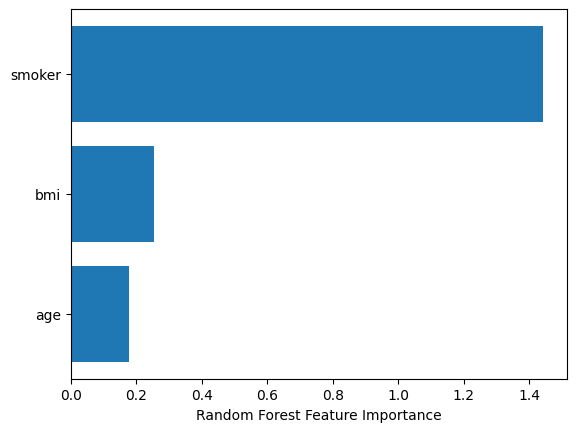

In [185]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(rf, X_test, y_test)

#let's plot
sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

In [187]:
import pickle

# save the model to disk
filename = 'model/charges.model'
pickle.dump(grid, open(filename, 'wb'))

In [188]:
loaded_model = pickle.load(open(filename, 'rb'))

In [192]:
df[['age', 'bmi', 'smoker', 'charges']].loc[1]

age          18.0000
bmi          33.7700
smoker        0.0000
charges    1725.5523
Name: 1, dtype: float64

In [195]:
sample = np.array([[18.00,0, 33.77]])

In [196]:
predicted_charges = loaded_model.predict(sample)
predicted_charges

array([12933.22191933])